<a href="https://colab.research.google.com/github/kuda940/project9/blob/main/Shopping_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas

In [2]:
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install sci_learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.45.0
    Uninstalling openai-2.45.0:
      Successfully uninstalled openai-2.45.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#connect to data path

In [9]:
data_path="/content/drive/MyDrive/shopping_trends_with_processdate.csv"

In [11]:
shopping_trends = pd.read_csv(data_path)

In [12]:
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,2025-03-13 02:32:18
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,2025-01-25 02:08:58
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,2025-05-11 00:04:53
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,2025-02-18 00:49:11
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,2025-06-15 20:04:47


In [13]:
#count the rows and columns

In [14]:
shopping_trends.shape

(3900, 19)

In [15]:
shopping_trends.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly,2025-04-01 00:09:23
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,2025-01-17 13:03:18
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly,2025-03-04 10:48:01
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly,2025-01-01 22:31:10
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly,2025-03-29 04:02:12


In [16]:
shopping_trends.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'processdate'],
      dtype='object')

In [17]:
shopping_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [18]:
shopping_trends.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [19]:
shopping_trends.T

,0,1,2,3,4,5,6,7,8,9,...,3890,3891,3892,3893,3894,3895,3896,3897,3898,3899
Customer ID,1,2,3,4,5,6,7,8,9,10,...,3891,3892,3893,3894,3895,3896,3897,3898,3899,3900
Age,55,19,50,21,45,46,63,27,26,57,...,35,36,35,21,66,40,52,46,44,52
Gender,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,...,Female,Female,Female,Female,Female,Female,Female,Female,Female,Female
Item Purchased,Blouse,Sweater,Jeans,Sandals,Blouse,Sneakers,Shirt,Shorts,Coat,Handbag,...,Shirt,Dress,Jewelry,Hat,Skirt,Hoodie,Backpack,Belt,Shoes,Handbag
Category,Clothing,Clothing,Clothing,Footwear,Clothing,Footwear,Clothing,Clothing,Outerwear,Accessories,...,Clothing,Clothing,Accessories,Accessories,Clothing,Clothing,Accessories,Accessories,Footwear,Accessories
Purchase Amount (USD),53,64,73,90,49,20,85,34,97,31,...,81,30,86,64,78,28,49,33,77,81
Location,Kentucky,Maine,Massachusetts,Rhode Island,Oregon,Wyoming,Montana,Louisiana,West Virginia,Missouri,...,Nebraska,Colorado,Michigan,Massachusetts,Connecticut,Virginia,Iowa,New Jersey,Minnesota,California
Size,L,L,S,M,M,M,M,L,L,M,...,XL,L,L,L,L,L,L,L,S,M
Color,Gray,Maroon,Maroon,Maroon,Turquoise,White,Gray,Charcoal,Silver,Pink,...,Green,Peach,Indigo,White,White,Turquoise,White,Green,Brown,Beige
Season,Winter,Winter,Spring,Spring,Spring,Summer,Fall,Winter,Summer,Spring,...,Winter,Winter,Summer,Fall,Spring,Summer,Spring,Spring,Summer,Spring


In [20]:
shopping_trends.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [21]:
#duplicates

In [22]:
shopping_trends.duplicated().sum()


np.int64(0)

In [23]:
shopping_trends.drop_duplicates(inplace=True)

In [24]:
shopping_trends.T

,0,1,2,3,4,5,6,7,8,9,...,3890,3891,3892,3893,3894,3895,3896,3897,3898,3899
Customer ID,1,2,3,4,5,6,7,8,9,10,...,3891,3892,3893,3894,3895,3896,3897,3898,3899,3900
Age,55,19,50,21,45,46,63,27,26,57,...,35,36,35,21,66,40,52,46,44,52
Gender,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,...,Female,Female,Female,Female,Female,Female,Female,Female,Female,Female
Item Purchased,Blouse,Sweater,Jeans,Sandals,Blouse,Sneakers,Shirt,Shorts,Coat,Handbag,...,Shirt,Dress,Jewelry,Hat,Skirt,Hoodie,Backpack,Belt,Shoes,Handbag
Category,Clothing,Clothing,Clothing,Footwear,Clothing,Footwear,Clothing,Clothing,Outerwear,Accessories,...,Clothing,Clothing,Accessories,Accessories,Clothing,Clothing,Accessories,Accessories,Footwear,Accessories
Purchase Amount (USD),53,64,73,90,49,20,85,34,97,31,...,81,30,86,64,78,28,49,33,77,81
Location,Kentucky,Maine,Massachusetts,Rhode Island,Oregon,Wyoming,Montana,Louisiana,West Virginia,Missouri,...,Nebraska,Colorado,Michigan,Massachusetts,Connecticut,Virginia,Iowa,New Jersey,Minnesota,California
Size,L,L,S,M,M,M,M,L,L,M,...,XL,L,L,L,L,L,L,L,S,M
Color,Gray,Maroon,Maroon,Maroon,Turquoise,White,Gray,Charcoal,Silver,Pink,...,Green,Peach,Indigo,White,White,Turquoise,White,Green,Brown,Beige
Season,Winter,Winter,Spring,Spring,Spring,Summer,Fall,Winter,Summer,Spring,...,Winter,Winter,Summer,Fall,Spring,Summer,Spring,Spring,Summer,Spring


In [25]:
#data manipulation

In [26]:
#add days of the week column

In [28]:
shopping_trends['processdate'] = pd.to_datetime(shopping_trends['processdate'])
shopping_trends['Day of the Week'] = shopping_trends['processdate'].dt.day_name()

In [29]:
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate,Day of the Week
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,2025-03-13 02:32:18,Thursday
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,2025-01-25 02:08:58,Saturday
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,2025-05-11 00:04:53,Sunday
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,2025-02-18 00:49:11,Tuesday
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,2025-06-15 20:04:47,Sunday


In [30]:
#add months of the year

In [32]:
shopping_trends['Month of the Year'] = shopping_trends['processdate'].dt.month_name()

In [33]:
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate,Day of the Week,Month of the Year
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,2025-03-13 02:32:18,Thursday,March
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,Yes,2,Cash,Fortnightly,2025-01-25 02:08:58,Saturday,January
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,2025-05-11 00:04:53,Sunday,May
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,2025-02-18 00:49:11,Tuesday,February
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,2025-06-15 20:04:47,Sunday,June


In [34]:
#add years columns

In [35]:
shopping_trends['Year'] = shopping_trends['processdate'].dt.year

In [36]:
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate,Day of the Week,Month of the Year,Year
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Express,Yes,Yes,14,Venmo,Fortnightly,2025-03-13 02:32:18,Thursday,March,2025
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Express,Yes,Yes,2,Cash,Fortnightly,2025-01-25 02:08:58,Saturday,January,2025
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Free Shipping,Yes,Yes,23,Credit Card,Weekly,2025-05-11 00:04:53,Sunday,May,2025
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Next Day Air,Yes,Yes,49,PayPal,Weekly,2025-02-18 00:49:11,Tuesday,February,2025
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Free Shipping,Yes,Yes,31,PayPal,Annually,2025-06-15 20:04:47,Sunday,June,2025


In [37]:
# separate process date into two columns namely date and the other time

In [38]:
shopping_trends['Date'] = shopping_trends['processdate'].dt.date

In [39]:
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate,Day of the Week,Month of the Year,Year,Date
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Yes,14,Venmo,Fortnightly,2025-03-13 02:32:18,Thursday,March,2025,2025-03-13
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Yes,2,Cash,Fortnightly,2025-01-25 02:08:58,Saturday,January,2025,2025-01-25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Yes,23,Credit Card,Weekly,2025-05-11 00:04:53,Sunday,May,2025,2025-05-11
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Yes,49,PayPal,Weekly,2025-02-18 00:49:11,Tuesday,February,2025,2025-02-18
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Yes,31,PayPal,Annually,2025-06-15 20:04:47,Sunday,June,2025,2025-06-15


In [40]:
#add time column

In [42]:
shopping_trends['Time'] = shopping_trends['processdate'].dt.time

In [43]:
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,processdate,Day of the Week,Month of the Year,Year,Date,Time
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,2025-03-13 02:32:18,Thursday,March,2025,2025-03-13,02:32:18
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,2025-01-25 02:08:58,Saturday,January,2025,2025-01-25,02:08:58
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,2025-05-11 00:04:53,Sunday,May,2025,2025-05-11,00:04:53
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,2025-02-18 00:49:11,Tuesday,February,2025,2025-02-18,00:49:11
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,2025-06-15 20:04:47,Sunday,June,2025,2025-06-15,20:04:47


In [44]:
# group by age

In [46]:
bins = [0, 12, 17, 64, np.inf]
labels = ['Children', 'Adolescents', 'Adults', 'Seniors']
shopping_trends['Age Group'] = pd.cut(shopping_trends['Age'], bins=bins, labels=labels, right=False)
shopping_trends.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,processdate,Day of the Week,Month of the Year,Year,Date,Time,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,14,Venmo,Fortnightly,2025-03-13 02:32:18,Thursday,March,2025,2025-03-13,02:32:18,Adults
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,2,Cash,Fortnightly,2025-01-25 02:08:58,Saturday,January,2025,2025-01-25,02:08:58,Adults
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,23,Credit Card,Weekly,2025-05-11 00:04:53,Sunday,May,2025,2025-05-11,00:04:53,Adults
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,49,PayPal,Weekly,2025-02-18 00:49:11,Tuesday,February,2025,2025-02-18,00:49:11,Adults
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,31,PayPal,Annually,2025-06-15 20:04:47,Sunday,June,2025,2025-06-15,20:04:47,Adults


In [47]:
avg_purchase_by_age_group = shopping_trends.groupby('Age Group')['Purchase Amount (USD)'].mean().reset_index()
display(avg_purchase_by_age_group)

/tmp/ipykernel_10520/1605827276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_purchase_by_age_group = shopping_trends.groupby('Age Group')['Purchase Amount (USD)'].mean().reset_index()


,Age Group,Purchase Amount (USD)
0,Children,NaN
1,Adolescents,NaN
2,Adults,59.828529
3,Seniors,59.328000


In [49]:
#group by amount purchased amount

In [50]:
shopping_trends['Purchase Amount (USD)'] = shopping_trends['Purchase Amount (USD)'].astype(float)

In [51]:
#visualize by time of the sale

In [53]:
shopping_trends['Time'].head()

,Time
0,02:32:18
1,02:08:58
2,00:04:53
3,00:49:11
4,20:04:47


In [54]:
# create visuals by category

In [55]:
shopping_trends['Category'].head()

,Category
0,Clothing
1,Clothing
2,Clothing
3,Footwear
4,Clothing


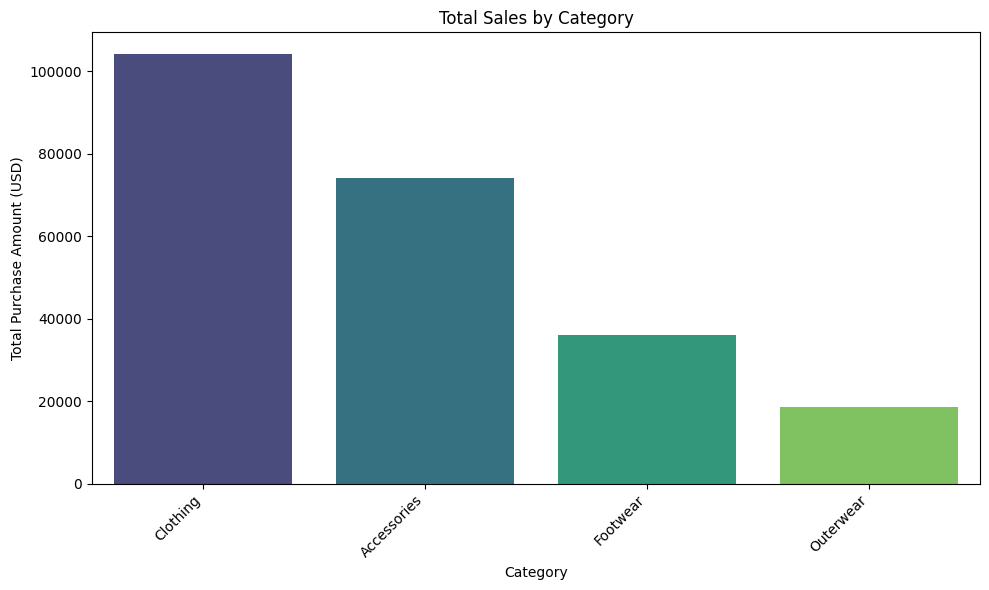

In [59]:
category_sales = shopping_trends.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Purchase Amount (USD)', data=category_sales, palette='viridis', hue='Category', legend=False)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

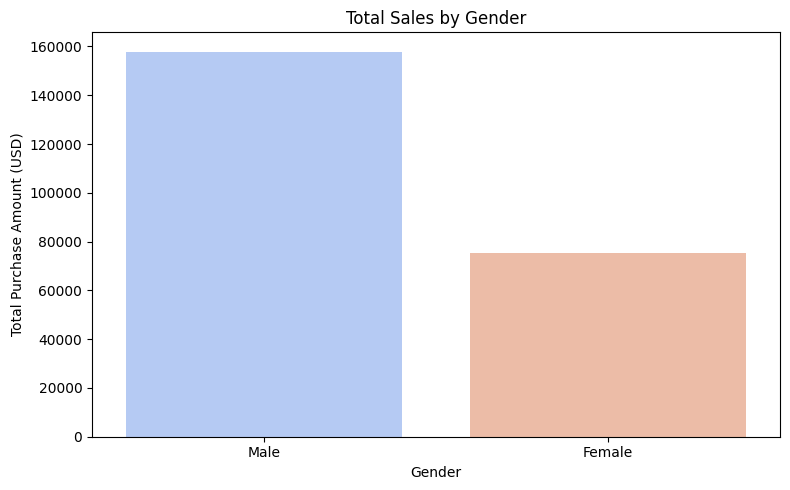

In [62]:
gender_sales = shopping_trends.groupby('Gender')['Purchase Amount (USD)'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='Purchase Amount (USD)', data=gender_sales, palette='coolwarm', hue='Gender', legend=False)
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount (USD)')
plt.tight_layout()
plt.show()

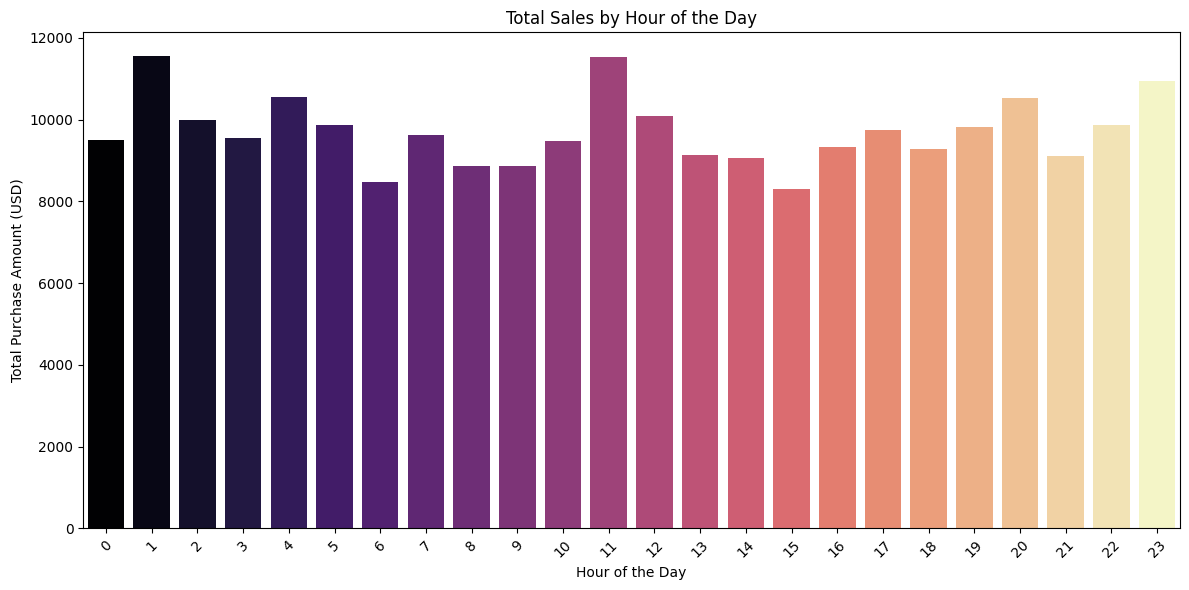

In [64]:
# Extract hour from the 'Time' column
shopping_trends['Sale_Hour'] = shopping_trends['processdate'].dt.hour

# Group by hour and sum purchase amounts
hourly_sales = shopping_trends.groupby('Sale_Hour')['Purchase Amount (USD)'].sum().reset_index()

# Create the bar plot for sales by hour
plt.figure(figsize=(12, 6))
sns.barplot(x='Sale_Hour', y='Purchase Amount (USD)', data=hourly_sales, palette='magma', hue='Sale_Hour', legend=False)
plt.title('Total Sales by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

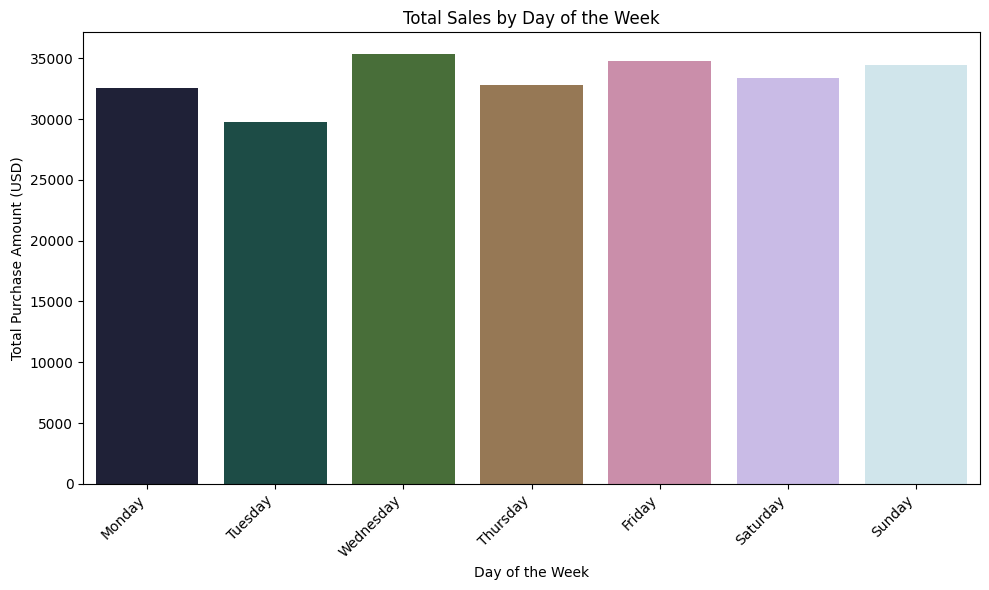

In [65]:
# Group by 'Day of the Week' and sum purchase amounts
day_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = shopping_trends.groupby('Day of the Week')['Purchase Amount (USD)'].sum().reindex(day_of_week_order).reset_index()

# Create the bar plot for sales by day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x='Day of the Week', y='Purchase Amount (USD)', data=day_sales, palette='cubehelix', hue='Day of the Week', legend=False)
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

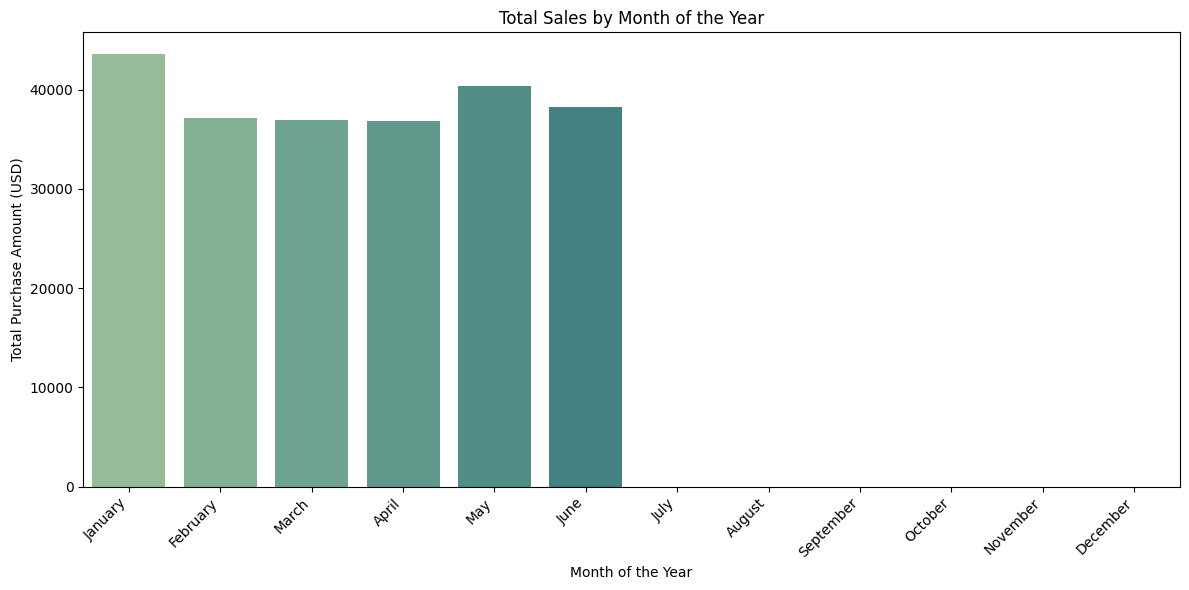

In [67]:
# Group by 'Month of the Year' and sum purchase amounts
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = shopping_trends.groupby('Month of the Year')['Purchase Amount (USD)'].sum().reindex(month_order).reset_index()

# Create the bar plot for sales by month
plt.figure(figsize=(12, 6))
sns.barplot(x='Month of the Year', y='Purchase Amount (USD)', data=monthly_sales, palette='crest', hue='Month of the Year', legend=False)
plt.title('Total Sales by Month of the Year')
plt.xlabel('Month of the Year')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

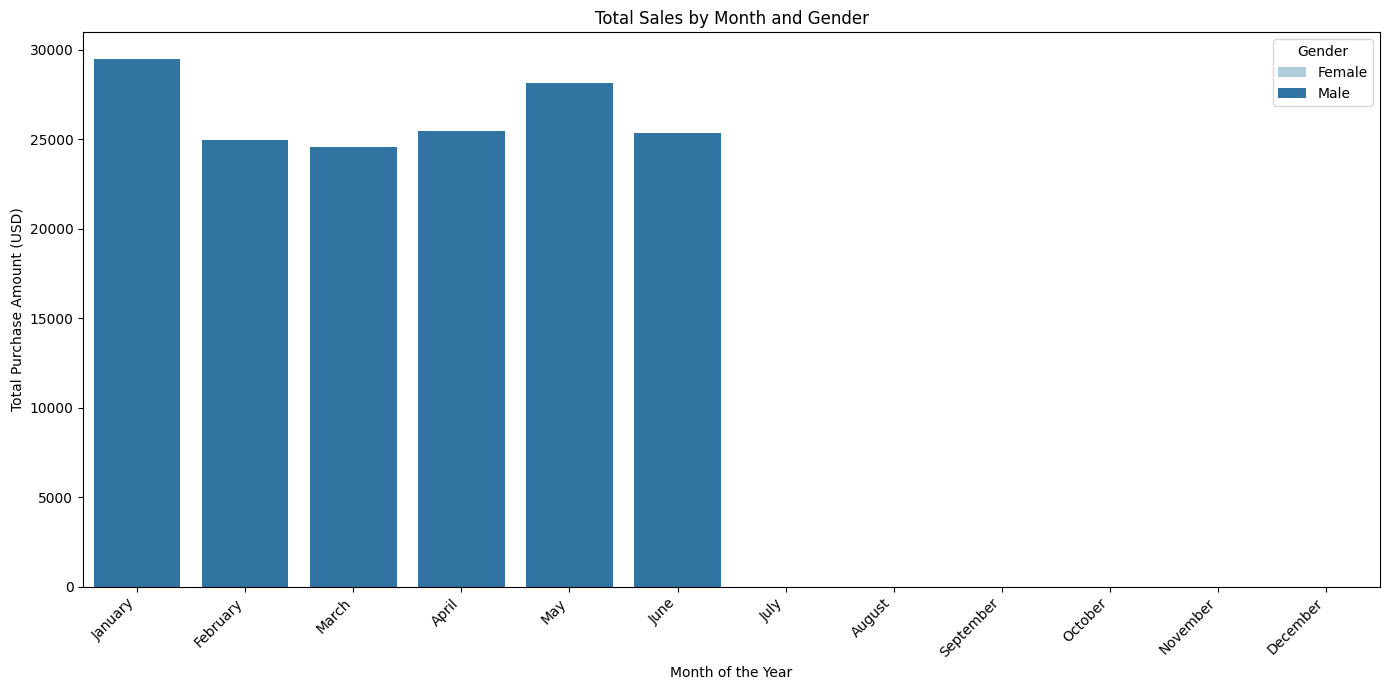

In [69]:
# Group by 'Month of the Year' and 'Gender' and sum purchase amounts
monthly_gender_sales = shopping_trends.groupby(['Month of the Year', 'Gender'])['Purchase Amount (USD)'].sum().reset_index()

# Ensure correct month order for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_gender_sales['Month of the Year'] = pd.Categorical(monthly_gender_sales['Month of the Year'], categories=month_order, ordered=True)
monthly_gender_sales = monthly_gender_sales.sort_values('Month of the Year')

# Create the grouped bar plot for sales by month and gender
plt.figure(figsize=(14, 7))
sns.barplot(x='Month of the Year', y='Purchase Amount (USD)', hue='Gender', data=monthly_gender_sales, palette='Paired')
plt.title('Total Sales by Month and Gender')
plt.xlabel('Month of the Year')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

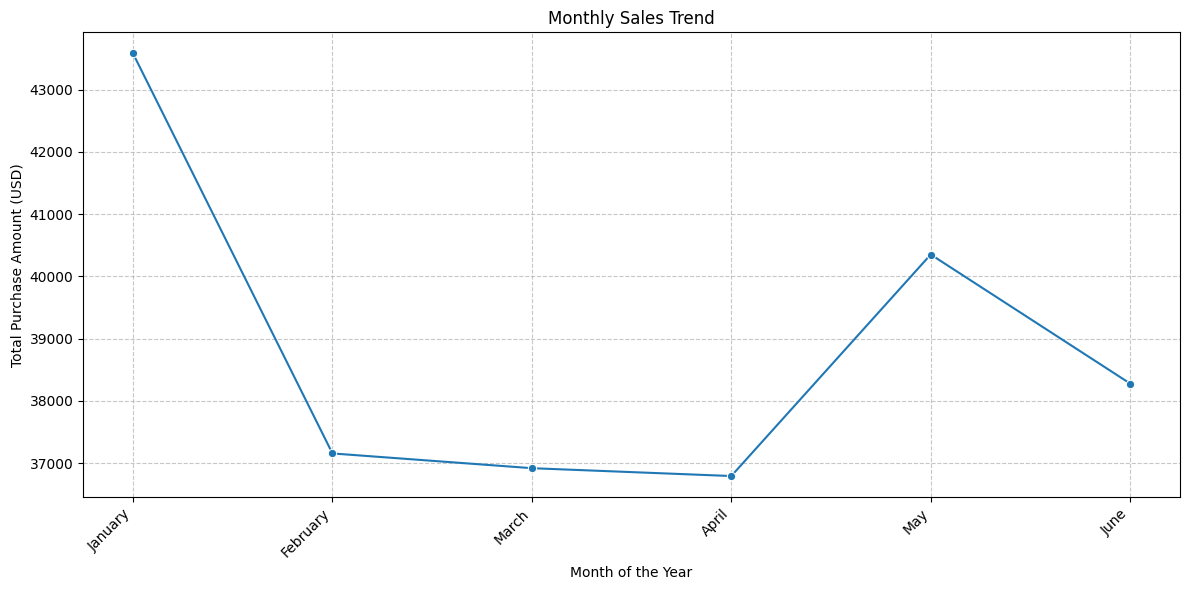

In [76]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month of the Year', y='Purchase Amount (USD)', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month of the Year')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

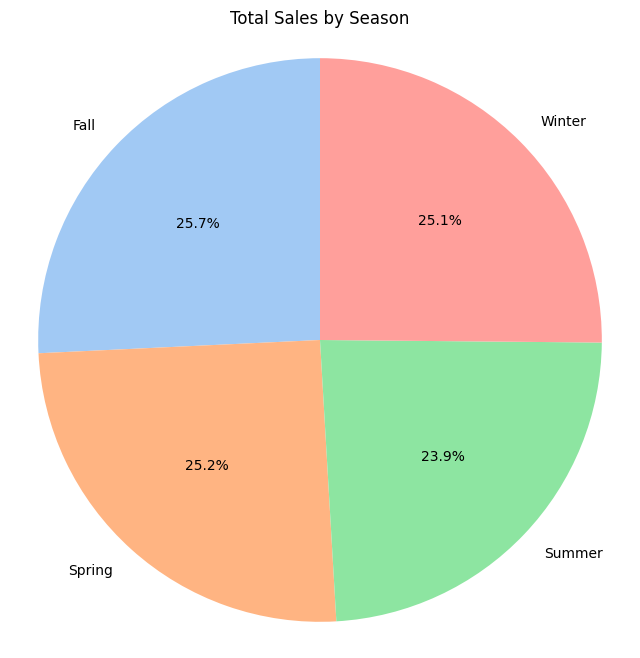

In [71]:
season_sales = shopping_trends.groupby('Season')['Purchase Amount (USD)'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(season_sales['Purchase Amount (USD)'], labels=season_sales['Season'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Total Sales by Season')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

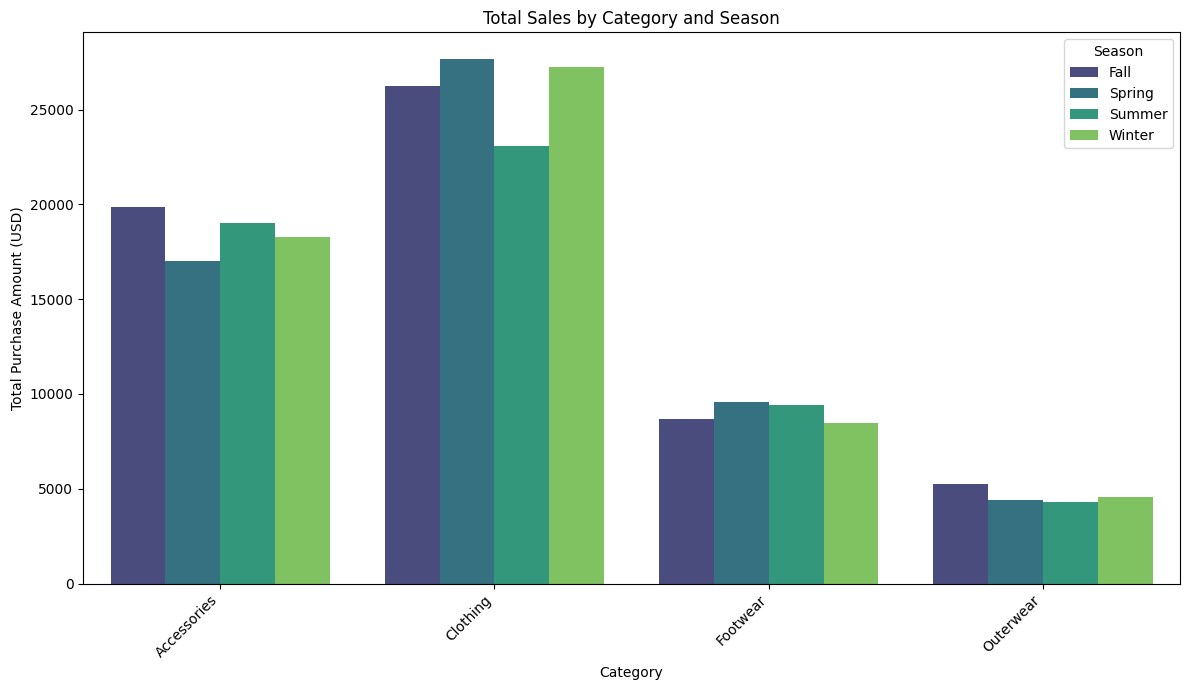

In [73]:
category_season_sales = shopping_trends.groupby(['Category', 'Season'])['Purchase Amount (USD)'].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Purchase Amount (USD)', hue='Season', data=category_season_sales, palette='viridis')
plt.title('Total Sales by Category and Season')
plt.xlabel('Category')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [74]:
visuals by sales and time grouped

SyntaxError: invalid syntax (3924405583.py, line 1)

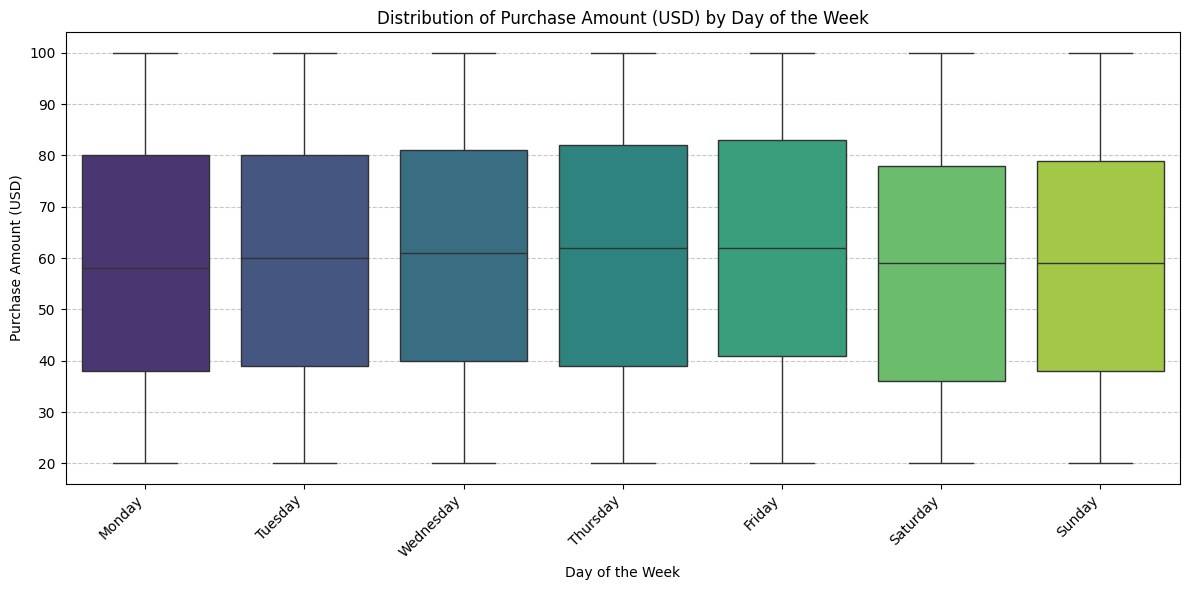

In [78]:
# Ensure 'Day of the Week' is ordered correctly for plotting
shopping_trends['Day of the Week'] = pd.Categorical(shopping_trends['Day of the Week'], categories=day_of_week_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Day of the Week', y='Purchase Amount (USD)', data=shopping_trends, palette='viridis', hue='Day of the Week', legend=False)
plt.title('Distribution of Purchase Amount (USD) by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [75]:
correlation_age_purchase = shopping_trends['Age'].corr(shopping_trends['Purchase Amount (USD)'])
print(f"Correlation between Age and Purchase Amount (USD): {correlation_age_purchase:.2f}")

Correlation between Age and Purchase Amount (USD): -0.01


In [79]:
from scipy import stats

male_spending = shopping_trends[shopping_trends['Gender'] == 'Male']['Purchase Amount (USD)']
female_spending = shopping_trends[shopping_trends['Gender'] == 'Female']['Purchase Amount (USD)']

t_stat, p_value = stats.ttest_ind(male_spending, female_spending, equal_var=False) # Welch's t-test, assuming unequal variances

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nBased on the p-value, the difference in spending between genders is statistically significant.")
else:
    print("\nBased on the p-value, there is no statistically significant difference in spending between genders.")

T-statistic: -0.882
P-value: 0.378

Based on the p-value, there is no statistically significant difference in spending between genders.


In [80]:
Give me summary

SyntaxError: invalid syntax (1649681661.py, line 1)

In [83]:
display(category_sales.head(5))

,Category,Purchase Amount (USD)
0,Clothing,104264.0
1,Accessories,74200.0
2,Footwear,36093.0
3,Outerwear,18524.0


In [82]:
# Define a mapping for frequency to a numerical scale (e.g., purchases per year)
frequency_mapping = {
    'Annually': 1,
    'Every 3 Months': 4, # Approximately 4 times a year
    'Quarterly': 4,
    'Bi-Weekly': 26,     # 52 weeks / 2 = 26
    'Fortnightly': 26,   # Same as Bi-Weekly
    'Weekly': 52,
    'Daily': 365
}

# Apply the mapping to create a new numerical column
shopping_trends['Frequency_Numeric'] = shopping_trends['Frequency of Purchases'].map(frequency_mapping)

# Calculate the correlation between 'Purchase Amount (USD)' and the new numerical frequency column
correlation_purchase_frequency = shopping_trends['Purchase Amount (USD)'].corr(shopping_trends['Frequency_Numeric'])

print(f"Correlation between Purchase Amount (USD) and Frequency of Purchases: {correlation_purchase_frequency:.2f}")

Correlation between Purchase Amount (USD) and Frequency of Purchases: -0.02


In [81]:
clothing_items = shopping_trends[shopping_trends['Category'] == 'Clothing']
popular_clothing_items = clothing_items['Item Purchased'].value_counts().reset_index()
popular_clothing_items.columns = ['Item Purchased', 'Count']
display(popular_clothing_items.head(10))

,Item Purchased,Count
0,Blouse,171
1,Pants,171
2,Shirt,169
3,Dress,166
4,Sweater,164
5,Socks,159
6,Skirt,158
7,Shorts,157
8,Hoodie,151
9,T-shirt,147


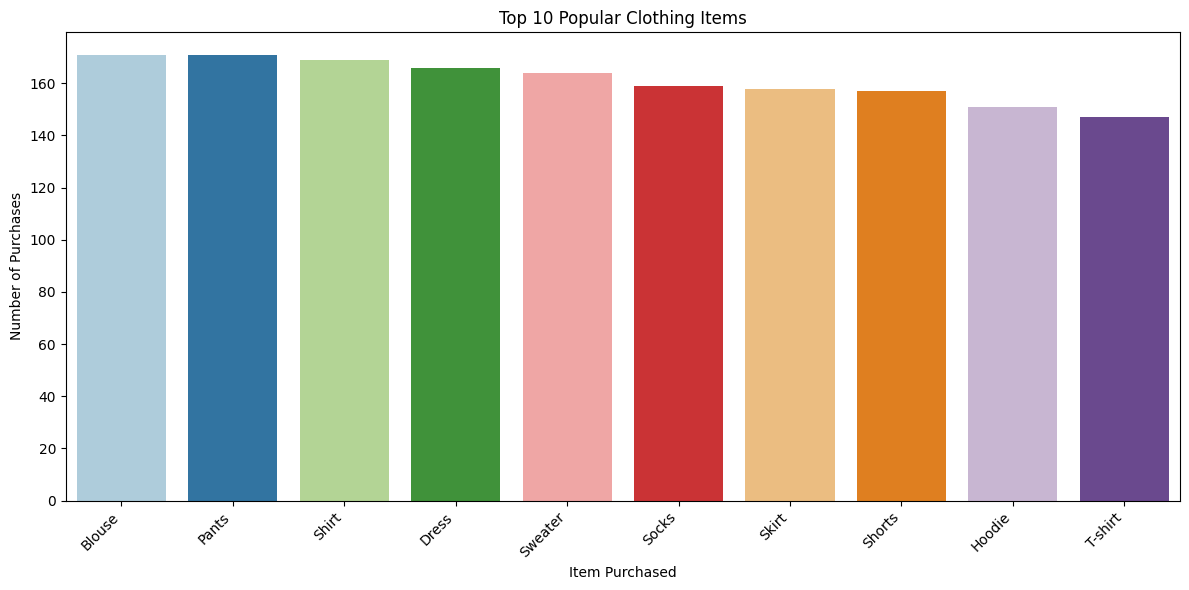

In [85]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Item Purchased', y='Count', data=popular_clothing_items.head(10), palette='Paired', hue='Item Purchased', legend=False)
plt.title('Top 10 Popular Clothing Items')
plt.xlabel('Item Purchased')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

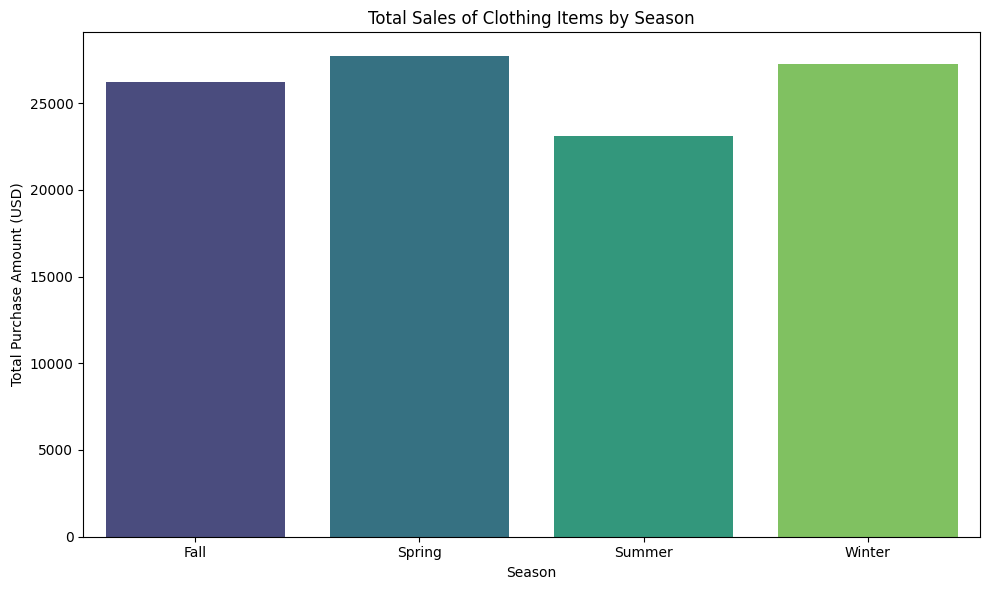

In [86]:
clothing_sales_by_season = shopping_trends[shopping_trends['Category'] == 'Clothing'].groupby('Season')['Purchase Amount (USD)'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Purchase Amount (USD)', data=clothing_sales_by_season, palette='viridis', hue='Season', legend=False)
plt.title('Total Sales of Clothing Items by Season')
plt.xlabel('Season')
plt.ylabel('Total Purchase Amount (USD)')
plt.tight_layout()
plt.show()

This table shows the most popular items purchased within the 'Clothing' category, based on their frequency in the dataset.